<a href="https://colab.research.google.com/github/FarzaadShojaei/AppDevelopersBlog/blob/FirstTest/MyBiscuitProject_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mlxtend pandas matplotlib networkx

### Load Data from Google Drive

First, we need to mount Google Drive to access files stored there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now that Google Drive is mounted, I will load the `ecommerce_transactions.csv` file into a pandas DataFrame. Please ensure the file is located at the specified path.

In [ ]:
import pandas as pd

csv_file_path = "/content/drive/MyDrive/ColabNotebooks/ecommerce_transactions.csv"

try:
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded data from {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: File not found at {csv_file_path}. Please ensure the file exists and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded data from /content/drive/MyDrive/ColabNotebooks/ecommerce_transactions.csv


,transaction_id,item,category,price
0,1,Coffee Mug,Lifestyle,11.0
1,1,Keyboard,Electronics,49.0
2,1,Laptop Stand,Electronics,29.0
3,1,Mouse,Electronics,25.0
4,2,Coffee Mug,Lifestyle,11.0


### Making subsequent code blocks more independent

To ensure that you don't always need to run all previous cells, especially if you restart the kernel or jump to a later part of the notebook, you can add checks for the existence of your DataFrame (`df`). If `df` is not present, the code will attempt to reload it. This assumes that Google Drive is already mounted and authorized in the current session.

The following cell demonstrates this pattern for a common initial data exploration step.

In [ ]:
# --- Self-contained Data Check and Initial Exploration ---

import pandas as pd
import os

# Define the file path (should match the one used earlier)
csv_file_path = "/content/drive/MyDrive/ecommerce_transactions.csv"

# Check if 'df' DataFrame exists in the current session's global scope
# and is an instance of a pandas DataFrame
if 'df' not in globals() or not isinstance(df, pd.DataFrame):
    print("DataFrame 'df' not found or not a valid DataFrame. Attempting to load data...")

    # Basic check if Drive might be mounted, though actual mount state requires interaction
    if not os.path.exists('/content/drive/MyDrive'):
        print("Warning: Google Drive directory '/content/drive/MyDrive' not found. Please ensure Drive is mounted via 'drive.mount('/content/drive')' and authorized.")

    try:
        df = pd.read_csv(csv_file_path)
        print(f"Data reloaded successfully from {csv_file_path}")
    except FileNotFoundError:
        print(f"Error: File not found at {csv_file_path}. Please verify the path and ensure the file exists on your Google Drive.")
        df = None # Set df to None to indicate loading failed
    except Exception as e:
        print(f"An unexpected error occurred during data reloading: {e}")
        df = None # Set df to None to indicate loading failed
else:
    print("DataFrame 'df' already exists in the current session.")

# Proceed with analysis only if df is successfully loaded/available
if df is not None:
    print("\n--- Initial Data Exploration ---")
    print("First 5 rows of the DataFrame:")
    display(df.head())

    print("\nDataFrame Info:")
    df.info()

    print("\nBasic descriptive statistics:")
    display(df.describe(include='all'))
else:
    print("Cannot proceed with analysis as DataFrame 'df' is not available.")

DataFrame 'df' already exists in the current session.

--- Initial Data Exploration ---
First 5 rows of the DataFrame:


,transaction_id,item,category,price
0,1,Coffee Mug,Lifestyle,11.0
1,1,Keyboard,Electronics,49.0
2,1,Laptop Stand,Electronics,29.0
3,1,Mouse,Electronics,25.0
4,2,Coffee Mug,Lifestyle,11.0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8156 entries, 0 to 8155
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  8156 non-null   int64  
 1   item            8156 non-null   object 
 2   category        8156 non-null   object 
 3   price           8156 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 255.0+ KB

Basic descriptive statistics:


,transaction_id,item,category,price
count,8156.000000,8156,8156,8156.000000
unique,NaN,25,7,NaN
top,NaN,Pen,Stationery,NaN
freq,NaN,699,3501,NaN
mean,796.723762,NaN,NaN,24.704819
std,464.859174,NaN,NaN,23.664939
min,1.000000,NaN,NaN,1.500000
25%,390.000000,NaN,NaN,5.000000
50%,800.000000,NaN,NaN,15.000000
75%,1201.000000,NaN,NaN,42.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df["item"] = df["item"].str.strip()
df["category"] = df["category"].str.strip()

df = df.drop_duplicates(subset=["transaction_id", "item"])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
basket = (
    df.assign(value=1)
    .pivot_table(
        index="transaction_id",
        columns="item",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

basket = basket.astype(bool)
basket.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

item,Backpack,Binder,Book A,Book B,Book C,Book D,Calculator,Coffee Mug,Desk Lamp,Eraser,...,Mouse,Notebook,Pen,Pencil,Phone Charger,Planner,Sticky Notes,Tablet Cover,USB Cable,Water Bottle
transaction_id,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
4,False,False,False,True,False,True,False,False,False,False,...,False,True,True,False,False,False,False,False,False,False
5,False,False,True,True,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

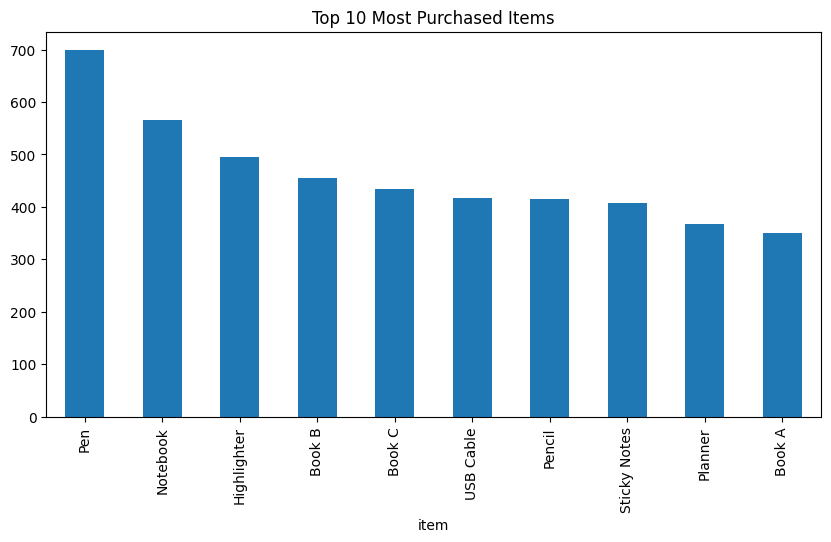

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
item_freq = basket.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
item_freq.head(10).plot(kind='bar')
plt.title("Top 10 Most Purchased Items")
plt.show()

In [ ]:
frequent_itemsets = apriori(
    basket,
    min_support=0.06,
    use_colnames=True
)

frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

frequent_itemsets.sort_values(by="support", ascending=False).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets,length
17,0.436875,(Pen),1
16,0.353125,(Notebook),1
12,0.309375,(Highlighter),1
3,0.284375,(Book B),1
4,0.271875,(Book C),1
23,0.260625,(USB Cable),1
18,0.259375,(Pencil),1
21,0.255000,(Sticky Notes),1
20,0.230000,(Planner),1
2,0.218750,(Book A),1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.25
)

rules = rules.sort_values(by=["lift", "confidence"], ascending=False)
rules.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
73,(Book A),"(Book B, Book C)",0.218750,0.097500,0.064375,0.294286,3.018315,1.0,0.043047,1.278846,0.855922,0.255583,0.218045,0.477271
72,"(Book B, Book C)",(Book A),0.097500,0.218750,0.064375,0.660256,3.018315,1.0,0.043047,2.299528,0.740930,0.255583,0.565128,0.477271
81,"(Sticky Notes, Pen)",(Planner),0.131875,0.230000,0.076875,0.582938,2.534515,1.0,0.046544,1.846250,0.697419,0.269737,0.458362,0.458589
84,(Planner),"(Sticky Notes, Pen)",0.230000,0.131875,0.076875,0.334239,2.534515,1.0,0.046544,1.303959,0.786295,0.269737,0.233105,0.458589
66,(USB Cable),(Phone Charger),0.260625,0.188750,0.120625,0.462830,2.452078,1.0,0.071432,1.510229,0.800923,0.366920,0.337849,0.550951
67,(Phone Charger),(USB Cable),0.188750,0.260625,0.120625,0.639073,2.452078,1.0,0.071432,2.048544,0.729963,0.366920,0.511848,0.550951
31,(Calculator),(Eraser),0.151875,0.193125,0.068125,0.448560,2.322639,1.0,0.038794,1.463214,0.671428,0.246050,0.316573,0.400655
32,(Eraser),(Calculator),0.193125,0.151875,0.068125,0.352751,2.322639,1.0,0.038794,1.310353,0.705754,0.246050,0.236847,0.400655
82,"(Planner, Pen)",(Sticky Notes),0.131250,0.255000,0.076875,0.585714,2.296919,1.0,0.043406,1.798276,0.649939,0.248485,0.443912,0.443592
83,(Sticky Notes),"(Planner, Pen)",0.255000,0.131250,0.076875,0.301471,2.296919,1.0,0.043406,1.243684,0.757898,0.248485,0.195937,0.443592


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
def clean_rules(rules_df):
    df = rules_df[['antecedents','consequents','support','confidence','lift']].copy()
    df['antecedents'] = df['antecedents'].apply(lambda x: ', '.join(list(x)))
    df['consequents'] = df['consequents'].apply(lambda x: ', '.join(list(x)))
    return df

clean_rules(rules).head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
73,Book A,"Book B, Book C",0.064375,0.294286,3.018315
72,"Book B, Book C",Book A,0.064375,0.660256,3.018315
81,"Sticky Notes, Pen",Planner,0.076875,0.582938,2.534515
84,Planner,"Sticky Notes, Pen",0.076875,0.334239,2.534515
66,USB Cable,Phone Charger,0.120625,0.462830,2.452078
67,Phone Charger,USB Cable,0.120625,0.639073,2.452078
31,Calculator,Eraser,0.068125,0.448560,2.322639
32,Eraser,Calculator,0.068125,0.352751,2.322639
82,"Planner, Pen",Sticky Notes,0.076875,0.585714,2.296919
83,Sticky Notes,"Planner, Pen",0.076875,0.301471,2.296919


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
strong_rules = rules[
    (rules['confidence'] >= 0.35) &
    (rules['lift'] > 1.1) &
    (rules['support'] >= 0.05)
].copy()

strong_rules.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
72,"(Book B, Book C)",(Book A),0.097500,0.218750,0.064375,0.660256,3.018315,1.0,0.043047,2.299528,0.740930,0.255583,0.565128,0.477271
81,"(Sticky Notes, Pen)",(Planner),0.131875,0.230000,0.076875,0.582938,2.534515,1.0,0.046544,1.846250,0.697419,0.269737,0.458362,0.458589
66,(USB Cable),(Phone Charger),0.260625,0.188750,0.120625,0.462830,2.452078,1.0,0.071432,1.510229,0.800923,0.366920,0.337849,0.550951
67,(Phone Charger),(USB Cable),0.188750,0.260625,0.120625,0.639073,2.452078,1.0,0.071432,2.048544,0.729963,0.366920,0.511848,0.550951
31,(Calculator),(Eraser),0.151875,0.193125,0.068125,0.448560,2.322639,1.0,0.038794,1.463214,0.671428,0.246050,0.316573,0.400655
32,(Eraser),(Calculator),0.193125,0.151875,0.068125,0.352751,2.322639,1.0,0.038794,1.310353,0.705754,0.246050,0.236847,0.400655
82,"(Planner, Pen)",(Sticky Notes),0.131250,0.255000,0.076875,0.585714,2.296919,1.0,0.043406,1.798276,0.649939,0.248485,0.443912,0.443592
70,"(Book A, Book B)",(Book C),0.105000,0.271875,0.064375,0.613095,2.255063,1.0,0.035828,1.881923,0.621847,0.206000,0.468629,0.424938
71,"(Book A, Book C)",(Book B),0.100625,0.284375,0.064375,0.639752,2.249676,1.0,0.035760,1.986476,0.617642,0.200780,0.496596,0.433063
34,(Calculator),(Pencil),0.151875,0.259375,0.077500,0.510288,1.967376,1.0,0.038107,1.512369,0.579760,0.232210,0.338786,0.404542


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def recommend_product(product, rules_df, top_n=5):
    results = []

    for _, row in rules_df.iterrows():
        if product in row['antecedents']:
            for item in row['consequents']:
                if item != product:
                    results.append({
                        "item": item,
                        "confidence": row['confidence'],
                        "lift": row['lift']
                    })

    rec = pd.DataFrame(results)

    if rec.empty:
        return rec

    rec = rec.sort_values(by=["lift", "confidence"], ascending=False)
    return rec.drop_duplicates().head(top_n)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
recommend_product("Book A", strong_rules)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,item,confidence,lift
0,Book C,0.613095,2.255063
1,Book B,0.639752,2.249676
2,Book C,0.460000,1.691954
3,Book B,0.480000,1.687912


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def recommend_cart(cart, rules_df, top_n=5):
    cart = set(cart)
    results = []

    for _, row in rules_df.iterrows():
        if set(row['antecedents']).issubset(cart):
            for item in row['consequents']:
                if item not in cart:
                    results.append({
                        "item": item,
                        "confidence": row['confidence'],
                        "lift": row['lift']
                    })

    rec = pd.DataFrame(results)

    if rec.empty:
        return rec

    rec = rec.sort_values(by=["lift","confidence"], ascending=False)
    return rec.drop_duplicates().head(top_n)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
prices = df.drop_duplicates("item").set_index("item")["price"].to_dict()

def bundle(product):
    recs = recommend_product(product, strong_rules, top_n=2)

    items = [product]
    if not recs.empty:
        items += recs["item"].tolist()

    total = sum(prices.get(i, 0) for i in items)

    print("Frequently Bought Together:")
    print(" + ".join(items))
    print("Total Price:", round(total, 2))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
fp_items = fpgrowth(
    basket,
    min_support=0.06,
    use_colnames=True
)

fp_rules = association_rules(
    fp_items,
    metric="confidence",
    min_threshold=0.25
)

len(fp_items), len(fp_rules)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

(83, 85)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
comparison = pd.DataFrame({
    "Method": ["Apriori", "FP-Growth"],
    "Itemsets": [len(frequent_itemsets), len(fp_items)],
    "Rules": [len(rules), len(fp_rules)]
})

comparison

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Method,Itemsets,Rules
0,Apriori,83,85
1,FP-Growth,83,85


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

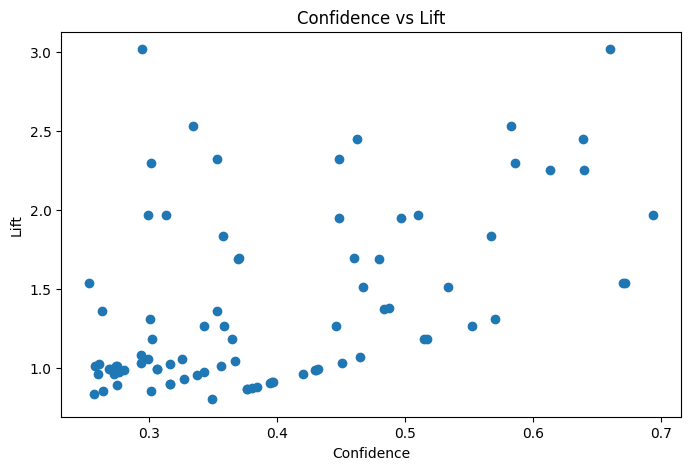

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(rules["confidence"], rules["lift"])
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift")
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

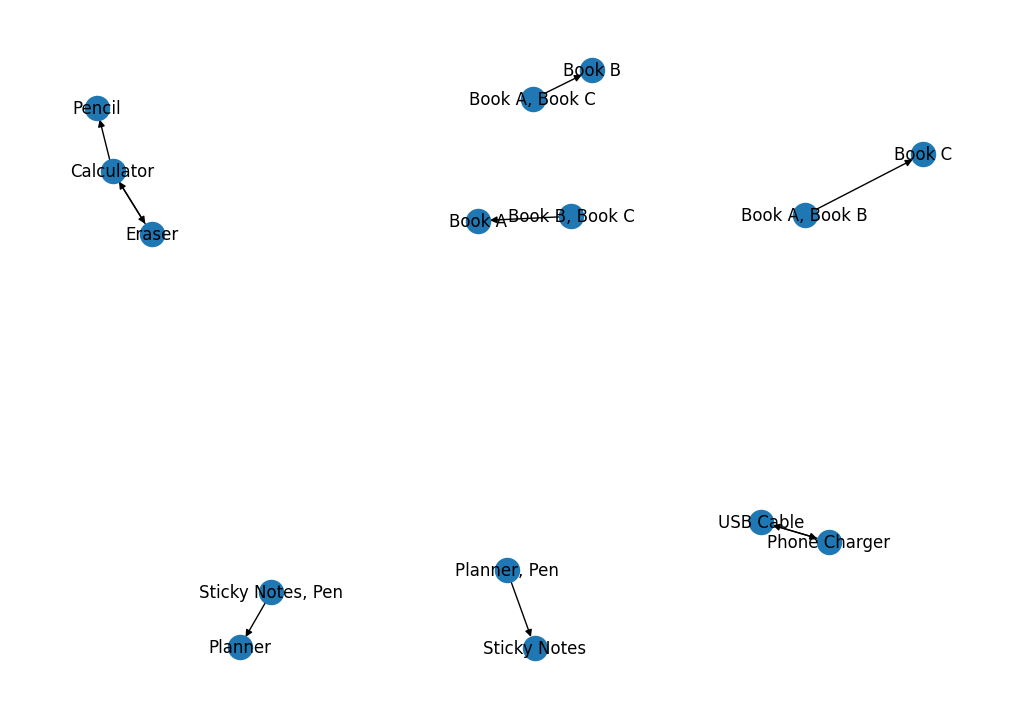

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
G = nx.DiGraph()

top_rules = strong_rules.head(10)

for _, row in top_rules.iterrows():
    a = ", ".join(list(row['antecedents']))
    c = ", ".join(list(row['consequents']))
    G.add_edge(a, c)

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
plt.show()